In [1]:
import numpy as np
import pandas as pd
import sqlalchemy as db
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from src.get_all_data import get_all_data
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib

In [2]:
engine = db.create_engine('sqlite:///../data/raw/data.db')
df = get_all_data(engine)

Searching for events

[+] US Federal Funds Rate
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Statement
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Press Conference
Skipped — next release on 2026-04-29 (not yet passed)

[+] US FOMC Economic Projections
Skipped — next release on 2026-06-17 (not yet passed)

[+] US Core CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI m/m
Skipped — next release on 2026-04-10 (not yet passed)

[+] US CPI y/y
Skipped — next release on 2026-04-10 (not yet passed)

[+] US PPI m/m
Skipped — next release on 2026-04-14 (not yet passed)

[+] US Core PCE Price Index m/m
Skipped — next release on 2026-04-09 (not yet passed)

[+] US Non-Farm Employment Change
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Unemployment Rate
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Average Hourly Earnings m/m
Skipped — next release on 2026-04-03 (not yet passed)

[+] US Advance GD

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2273 entries, 2007-03-29 to 2026-03-19
Columns: 167 entries, US Advance GDP q/q to US FOMC Statement
dtypes: float64(167)
memory usage: 2.9 MB


In [4]:
df.columns.tolist()

['US Advance GDP q/q',
 'US Average Hourly Earnings m/m',
 'US Building Permits',
 'US CPI m/m',
 'US CPI y/y',
 'US Core CPI m/m',
 'US Core PCE Price Index m/m',
 'US Core Retail Sales m/m',
 'US Existing Home Sales',
 'US Federal Funds Rate',
 'US Final GDP q/q',
 'US Housing Starts',
 'US ISM Manufacturing PMI',
 'US ISM Services PMI',
 'US New Home Sales',
 'US Non-Farm Employment Change',
 'US PPI m/m',
 'US Personal Income m/m',
 'US Personal Spending m/m',
 'US Prelim GDP q/q',
 'US Retail Sales m/m',
 'US Unemployment Rate',
 'FEDFUNDS',
 'DFF',
 'T10Y2Y',
 'T10Y3M',
 'GS10',
 'GS2',
 'BAMLH0A0HYM2',
 'BAMLC0A0CM',
 'NFCI',
 'UNRATE',
 'CPIAUCSL',
 'T5YIE',
 'T10YIE',
 'ICSA',
 'WALCL',
 'M2SL',
 'TEDRATE',
 'spy_open',
 'spy_high',
 'spy_low',
 'spy_close',
 'spy_volume',
 'spy_EMA_14',
 'spy_EMA_30',
 'spy_EMA_60',
 'spy_SMA_14',
 'spy_SMA_30',
 'spy_SMA_60',
 'spy_BB_upper',
 'spy_BB_middle',
 'spy_BB_lower',
 'spy_RSI_14',
 'spy_RSI_21',
 'spy_RSI_30',
 'spy_MACD',
 'spy_M

In [5]:
df.head()

,US Advance GDP q/q,US Average Hourly Earnings m/m,US Building Permits,US CPI m/m,US CPI y/y,US Core CPI m/m,US Core PCE Price Index m/m,US Core Retail Sales m/m,US Existing Home Sales,US Federal Funds Rate,...,gc=f_MACD_signal,gc=f_MACD_hist,gc=f_AROON_down,gc=f_AROON_up,gc=f_MFI,gc=f_AVGPRICE,gc=f_MEDPRICE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,0.895778,1.175966,21.428571,92.857143,21.635926,662.050003,660.399994,1490.0,1490.0,41.0
2007-03-30,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.161384,1.062423,14.285714,100.000000,28.540917,662.750000,663.399994,1489.0,1489.0,40.0
2007-04-02,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.435704,1.097282,7.142857,92.857143,27.775431,663.199997,660.799988,1486.0,1486.0,37.0
2007-04-04,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.994182,1.293880,0.000000,100.000000,30.387048,668.774994,669.500000,1484.0,1484.0,35.0
2007-04-13,0.035,0.003,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,4.358484,1.789605,28.571429,100.000000,30.706577,682.350006,681.899994,1475.0,1475.0,26.0


In [12]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df)
X_test_scaled = scaler.transform(test_df)

In [14]:
pca = PCA(n_components=0.90, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [29]:
def make_prior_from_durations(durations_days: list[float], n_states: int, alpha_off: float = 1.0) -> np.ndarray:

    prior = np.full((n_states, n_states), alpha_off)
    for i, duration in enumerate(durations_days):
        # p_ii = (D-1)/D → alpha_diag = (D-1)*(n-1)*alpha_off
        prior[i, i] = (duration - 1) * (n_states - 1) * alpha_off
    return prior
durations = [300, 200, 90]

n_states = 3
prior_matrix = make_prior_from_durations(durations, n_states)
print("Prior matrix:")
print(prior_matrix)

for i in range(n_states):
    p_ii = prior_matrix[i, i] / prior_matrix[i].sum()
    print(f"  State {i}: {1/(1-p_ii):.1f} days")

Prior matrix:
[[598.   1.   1.]
 [  1. 398.   1.]
 [  1.   1. 178.]]
  State 0: 300.0 days
  State 1: 200.0 days
  State 2: 90.0 days


In [30]:

prior_matrix = make_prior_from_durations(
    durations_days=durations,
    n_states=n_states,
    alpha_off=1.0
)

model = GaussianHMM(
    n_components=n_states,
    transmat_prior=prior_matrix,
    n_iter=2000,
    covariance_type="diag",
    random_state=42,

    tol=1e-4,
)
model.init_params = "stmc"
model.fit(X_train_pca)

print(f"Converged: {model.monitor_.converged}")
print(f"Log-likelihood: {model.score(X_train_pca):.2f}")

# learned durations
for i in range(n_states):
    p_ii = model.transmat_[i, i]
    print(f"  State {i}: {1/(1-p_ii+1e-9):.1f} days (p_ii={p_ii:.3f})")

Converged: True
Log-likelihood: -56698.16
  State 0: 435.3 days (p_ii=0.998)
  State 1: 235.5 days (p_ii=0.996)
  State 2: 274.0 days (p_ii=0.996)


In [31]:
train_df['state'] = model.predict(X_train_pca)
test_df['state'] = model.predict(X_test_pca)

In [32]:
df.head()

,US Advance GDP q/q,US Average Hourly Earnings m/m,US Building Permits,US CPI m/m,US CPI y/y,US Core CPI m/m,US Core PCE Price Index m/m,US Core Retail Sales m/m,US Existing Home Sales,US Federal Funds Rate,...,gc=f_MACD_signal,gc=f_MACD_hist,gc=f_AROON_down,gc=f_AROON_up,gc=f_MFI,gc=f_AVGPRICE,gc=f_MEDPRICE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2007-03-29,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,0.895778,1.175966,21.428571,92.857143,21.635926,662.050003,660.399994,1490.0,1490.0,41.0
2007-03-30,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.161384,1.062423,14.285714,100.000000,28.540917,662.750000,663.399994,1489.0,1489.0,40.0
2007-04-02,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.435704,1.097282,7.142857,92.857143,27.775431,663.199997,660.799988,1486.0,1486.0,37.0
2007-04-04,0.035,0.004,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,1.994182,1.293880,0.000000,100.000000,30.387048,668.774994,669.500000,1484.0,1484.0,35.0
2007-04-13,0.035,0.003,1530000.0,0.004,0.024,0.002,0.003,-0.001,6690000.0,0.0525,...,4.358484,1.789605,28.571429,100.000000,30.706577,682.350006,681.899994,1475.0,1475.0,26.0


In [33]:
df.tail()

,US Advance GDP q/q,US Average Hourly Earnings m/m,US Building Permits,US CPI m/m,US CPI y/y,US Core CPI m/m,US Core PCE Price Index m/m,US Core Retail Sales m/m,US Existing Home Sales,US Federal Funds Rate,...,gc=f_MACD_signal,gc=f_MACD_hist,gc=f_AROON_down,gc=f_AROON_up,gc=f_MFI,gc=f_AVGPRICE,gc=f_MEDPRICE,US FOMC Economic Projections,US FOMC Press Conference,US FOMC Statement
date,,,,,,,,,,,,,,,,,,,,,
2026-03-11,0.014,0.004,1390000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,92.416963,-13.839201,0.0,50.000000,85.270404,5179.224854,5179.349854,98.0,49.0,49.0
2026-03-12,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,88.104255,-17.250830,50.0,42.857143,84.653018,5126.500000,5126.500000,97.0,48.0,48.0
2026-03-13,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,82.419106,-22.740596,100.0,35.714286,23.664579,5073.050049,5073.250000,96.0,47.0,47.0
2026-03-18,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,56.453416,-40.666919,100.0,14.285714,23.533438,4902.700073,4885.650146,91.0,42.0,42.0
2026-03-19,0.014,0.004,1380000.0,0.003,0.024,0.002,0.004,0.0,4090000.0,0.0375,...,39.718072,-66.941379,100.0,7.142857,15.378079,4684.200073,4686.850098,90.0,41.0,41.0


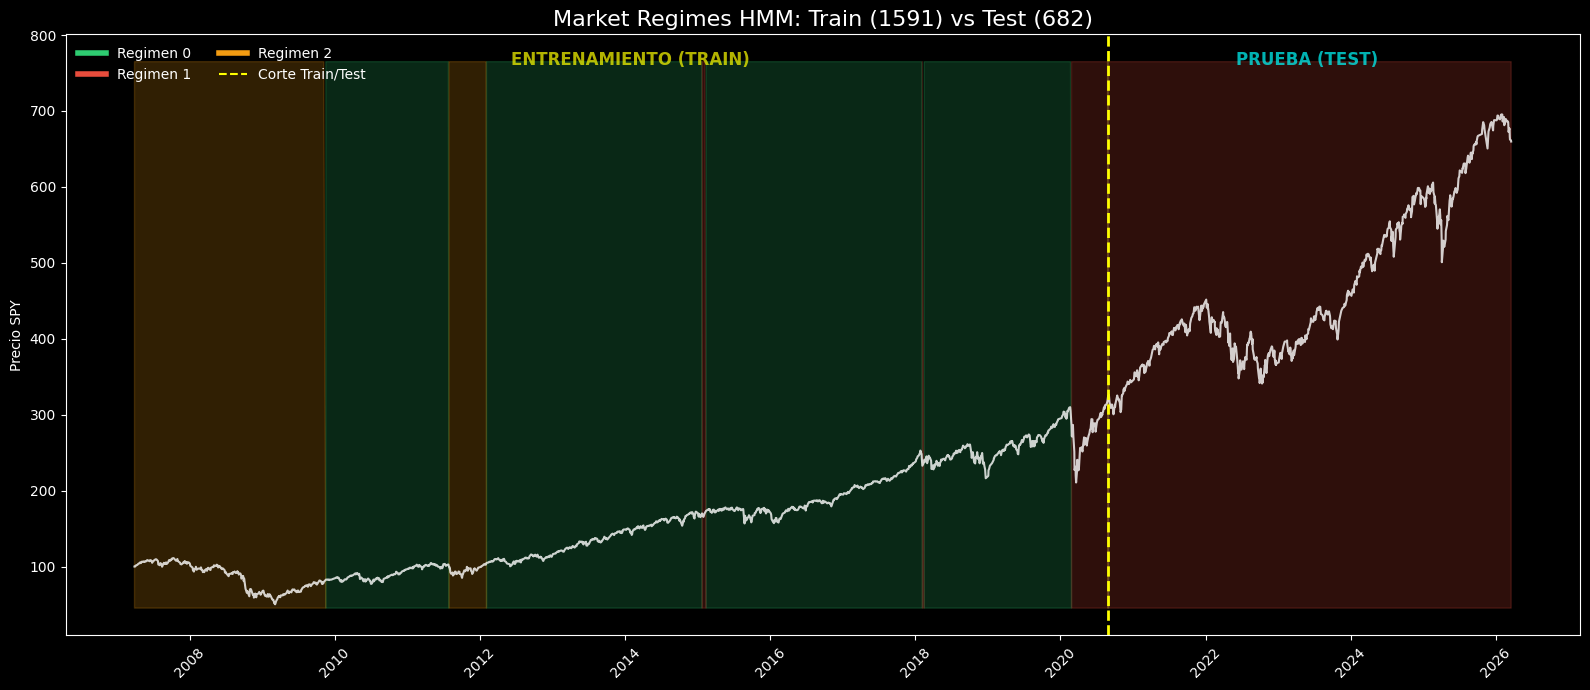

In [34]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Unimos los dataframes para tener la serie completa con sus estados
df_full = pd.concat([train_df, test_df]).sort_index()

plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(16, 7))

# Definir colores para los estados (ajusta n_states según tu modelo)
n_states = model.n_components
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#e84393'][:n_states]

# --- Graficar Precio SPY ---
ax.plot(df_full.index, df_full['spy_close'], color='white', lw=1.5, alpha=0.8, label='SPY Close')

# --- Graficar Regímenes (Fondo) ---
for regime_id, color in enumerate(colors):
    mask = df_full['state'] == regime_id
    ax.fill_between(
        df_full.index,
        df_full['spy_close'].min() * 0.9,
        df_full['spy_close'].max() * 1.1,
        where=mask, color=color, alpha=0.2, interpolate=True
    )

# --- Línea de división Train/Test ---
split_date = test_df.index[0]
ax.axvline(x=split_date, color='yellow', linestyle='--', lw=2, label='Separación Train/Test')

# --- Anotaciones de Texto ---
ax.text(train_df.index[int(len(train_df)/2)], ax.get_ylim()[1]*0.95, 'ENTRENAMIENTO (TRAIN)',
        color='yellow', fontsize=12, fontweight='bold', ha='center', alpha=0.7)
ax.text(test_df.index[int(len(test_df)/2)], ax.get_ylim()[1]*0.95, 'PRUEBA (TEST)',
        color='cyan', fontsize=12, fontweight='bold', ha='center', alpha=0.7)

# --- Estética y Formato ---
ax.set_title(f'Market Regimes HMM: Train ({len(train_df)}) vs Test ({len(test_df)})', fontsize=16)
ax.set_ylabel('Precio SPY')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=f'Regimen {i}') for i in range(n_states)]
legend_elements.append(Line2D([0], [0], color='yellow', linestyle='--', label='Corte Train/Test'))
ax.legend(handles=legend_elements, loc='upper left', frameon=False, ncol=2)

plt.tight_layout()
plt.show()

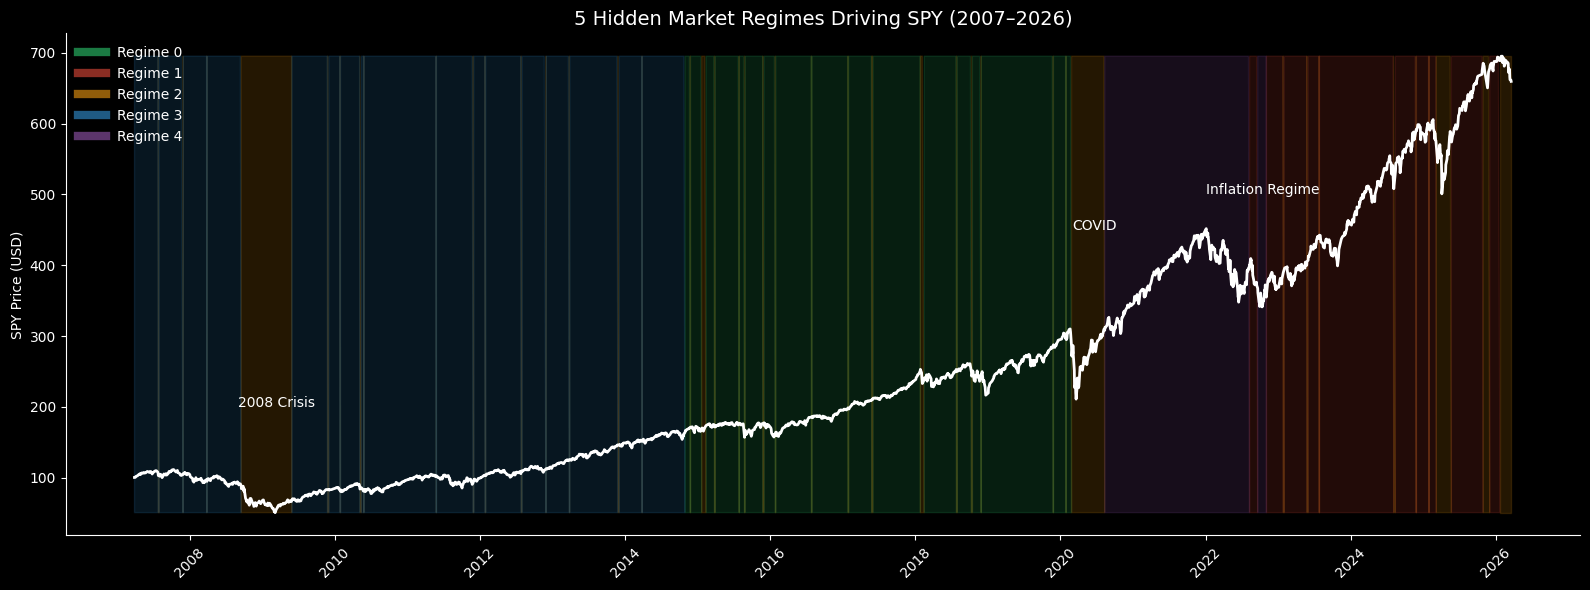

In [21]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(16, 6))

n_states = model.n_components

colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#e84393'][:n_states]

# ── SPY price ─────────────────────────────────────────────────────
ax.plot(df.index, df['spy_close'], color='white', lw=2)

ax.set_ylabel('SPY Price (USD)')
ax.set_title('5 Hidden Market Regimes Driving SPY (2007–2026)', fontsize=14)

# ── Regimes as background ─────────────────────────────────────────
for regime_id, color in enumerate(colors):
    mask = df['state'] == regime_id

    ax.fill_between(
        df.index,
        df['spy_close'].min(),
        df['spy_close'].max(),
        where=mask,
        color=color,
        alpha=0.15,
        interpolate=True
    )

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([0], [0], color=color, lw=6, alpha=0.6)
    for color in colors
]

labels = [f'Regime {i}' for i in range(n_states)]

ax.legend(handles, labels, loc='upper left', frameon=False)

ax.text(pd.Timestamp('2008-09-01'), 200, '2008 Crisis', color='white')
ax.text(pd.Timestamp('2020-03-01'), 450, 'COVID', color='white')
ax.text(pd.Timestamp('2022-01-01'), 500, 'Inflation Regime', color='white')

# ── Guardar ───────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('regimes_clean.png', dpi=300, bbox_inches='tight')

plt.show()